In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,md5,sha1,file_extension,EntryPoint,PEType,MachineType,magic_number,bytes_on_last_page,pages_in_file,relocations,...,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis,Class,Category,Family
0,d5aa2b2506dd71b65307bb551a6a099d,62f4d55a1bb8396e493d7815dc44febed7161535,exe,0x108ec,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0000,...,0,0,0,0,0,6,162,Benign,Benign,Benign
1,8d1178cec97f96a9ede3efe2f30ef30e,ca40945a4e35d48794a5e13aacf16b8ae1caddeb,exe,0x25cf9c,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0000,...,93,0,0,0,0,22,778,Benign,Benign,Benign
2,c08d7afb7966f452cf5aa9283fe8880a,6f47b50480bea61ae4dfb75c12582990cc5ce770,exe,0x2a7e,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,35,0,0,0,0,1,1,Benign,Benign,Benign
3,3554a3a99e7ffb57552aedcb2520f1d2,8c3d5b506a8d55f42f4c83ead3e4341255d1acfc,exe,0x64ca0,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0004,...,0,0,0,0,0,1,40,Benign,Benign,Benign
4,5be9511d42136df49d9501680e84109f,0a7d0c68c591db2f197b2169d226bebe6e9bdabe,exe,0x1b9ae,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,36,0,0,0,0,1,1,Benign,Benign,Benign


In [3]:
df.tail()

,md5,sha1,file_extension,EntryPoint,PEType,MachineType,magic_number,bytes_on_last_page,pages_in_file,relocations,...,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis,Class,Category,Family
21747,3aabbbed7dd5e3589f2387ec1a62471f,067d84bef48f6abc37226c6ccb981d21f7c8b93f,exe,0x889b6,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,29,0,0,0,0,1,1,Malware,Stealer,Snake
21748,c62343c3c6463795e88fe0a2a81c82b3,02df1939b04bc7de83c3029c5eb8e9b25cc9be91,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,32,0,0,0,0,1,1,Malware,Stealer,Snake
21749,db92e74aee2f64a0b40a64c1a014e257,fde61811f7ae53f9fa59e17fb5c2c6143a48b282,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,35,0,0,0,0,1,1,Malware,Stealer,Snake
21750,06e50d688d5b79ffea6135c7a55402cd,ad58274e8425775b284ee1f314f879100d437340,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,29,0,0,0,0,1,1,Malware,Stealer,Snake
21751,981de70f5242ac1192bf182be3797e1b,d7ac568899333c823c589444286f9d3655992332,exe,0xa13ae,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,33,1,0,1,0,0,0,Malware,Stealer,Snake


In [4]:
df.shape

(21752, 77)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

md5               0
sha1              0
file_extension    0
EntryPoint        0
PEType            0
                 ..
dlls_calls        0
apis              0
Class             0
Category          0
Family            0
Length: 77, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21752 entries, 0 to 21751
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   md5                         21752 non-null  object
 1   sha1                        21752 non-null  object
 2   file_extension              21752 non-null  object
 3   EntryPoint                  21752 non-null  object
 4   PEType                      21752 non-null  object
 5   MachineType                 21752 non-null  object
 6   magic_number                21752 non-null  object
 7   bytes_on_last_page          21752 non-null  object
 8   pages_in_file               21752 non-null  object
 9   relocations                 21752 non-null  object
 10  size_of_header              21752 non-null  object
 11  min_extra_paragraphs        21752 non-null  object
 12  max_extra_paragraphs        21752 non-null  object
 13  init_ss_value               21752 non-null  ob

In [8]:
df.describe()

,registry_read,registry_write,registry_delete,registry_total,network_threats,network_dns,network_http,network_connections,processes_malicious,processes_suspicious,processes_monitored,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis
count,2.175200e+04,21752.000000,21752.000000,2.175200e+04,21752.0,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.00000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000
mean,2.171168e+03,25.674053,3.680627,2.276478e+03,0.0,4.852657,1.844014,22.136861,1.820614,0.342497,8.272113,42.581602,8.36507,356.610656,72.548777,29.032135,4.621828,95.685408
std,2.409530e+04,294.948577,96.000378,2.421555e+04,0.0,39.940747,31.480131,220.420601,15.786036,3.082385,41.677590,51.766211,44.64347,1965.171138,371.995907,225.768247,5.784234,161.853316
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.400000e+01,0.000000,0.000000,2.100000e+01,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,34.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,2.960000e+02,0.000000,0.000000,2.710000e+02,0.0,0.000000,0.000000,2.000000,1.000000,0.000000,2.000000,37.000000,0.00000,0.000000,0.000000,0.000000,2.000000,32.000000
75%,9.892500e+02,3.000000,0.000000,1.082250e+03,0.0,1.000000,0.000000,6.000000,2.000000,0.000000,6.000000,44.000000,1.00000,4.000000,3.000000,1.000000,7.000000,127.000000
max,1.785397e+06,25409.000000,12609.000000,1.785649e+06,0.0,1339.000000,3846.000000,16407.000000,1350.000000,229.000000,3247.000000,3295.000000,1104.00000,63152.000000,9951.000000,14075.000000,134.000000,3575.000000


In [9]:
df.nunique()

md5               13903
sha1              13904
file_extension        1
EntryPoint         8325
PEType                3
                  ...  
dlls_calls           58
apis                769
Class                 2
Category              5
Family               27
Length: 77, dtype: int64

In [10]:
df.drop(columns=['md5', 'sha1'], inplace=True,errors='ignore')

y_class = df['Class'].apply(lambda x: 1 if x != 'Benign' else 0)  
y_family = df['Family']

X = df.drop(columns=['Class', 'Category', 'Family'])

def convert_hex(val):
    try:
        if isinstance(val, str) and val.startswith("0x"):
            return int(val, 16)
        return int(val)
    except:
        return val

X = X.applymap(convert_hex)
X = pd.get_dummies(X)
X_selected = X  
le = LabelEncoder()
y_family_encoded = le.fit_transform(y_family)

C:\Users\Gayathri\AppData\Local\Temp\ipykernel_19012\1939871516.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(convert_hex)


In [11]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X, y_class)

importances = selector_model.feature_importances_
feature_names = X.columns

top_k = 10
top_k_indices = np.argsort(importances)[-top_k:]
top_k_features = feature_names.to_numpy()[top_k_indices]
X_selected = X[top_k_features]

print("\nTop", top_k, "features used:")
for feature in top_k_features:
    print("-", feature)



Top 10 features used:
- network_http
- files_unknown
- total_procsses
- network_dns
- files_suspicious
- registry_read
- processes_monitored
- registry_total
- files_malicious
- processes_malicious


In [12]:
# Get importances of selected top features
selected_importances = importances[top_k_indices]

# Convert to percentage
total = selected_importances.sum()
contribution_percentages = (selected_importances / total) * 100

print("\nFeature Contribution Percentages (Detection):")
for i, feature in enumerate(top_k_features):
    print(f"{feature}: {contribution_percentages[i]:.2f}%")


Feature Contribution Percentages (Detection):
network_http: 4.74%
files_unknown: 5.05%
total_procsses: 5.52%
network_dns: 6.39%
files_suspicious: 8.02%
registry_read: 8.06%
processes_monitored: 8.49%
registry_total: 8.51%
files_malicious: 13.28%
processes_malicious: 31.95%


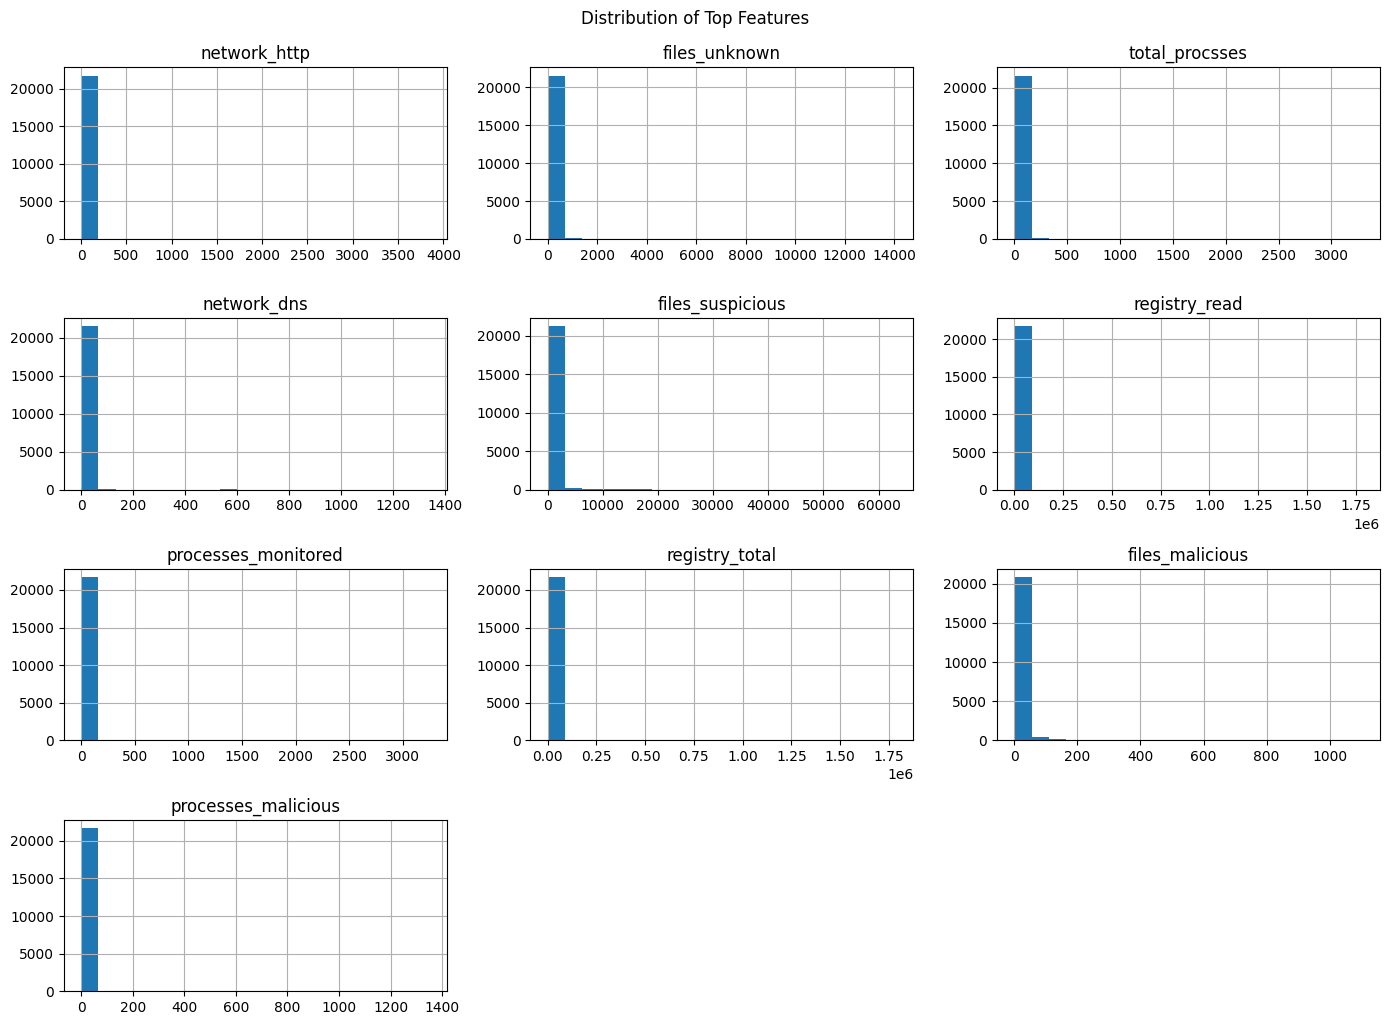

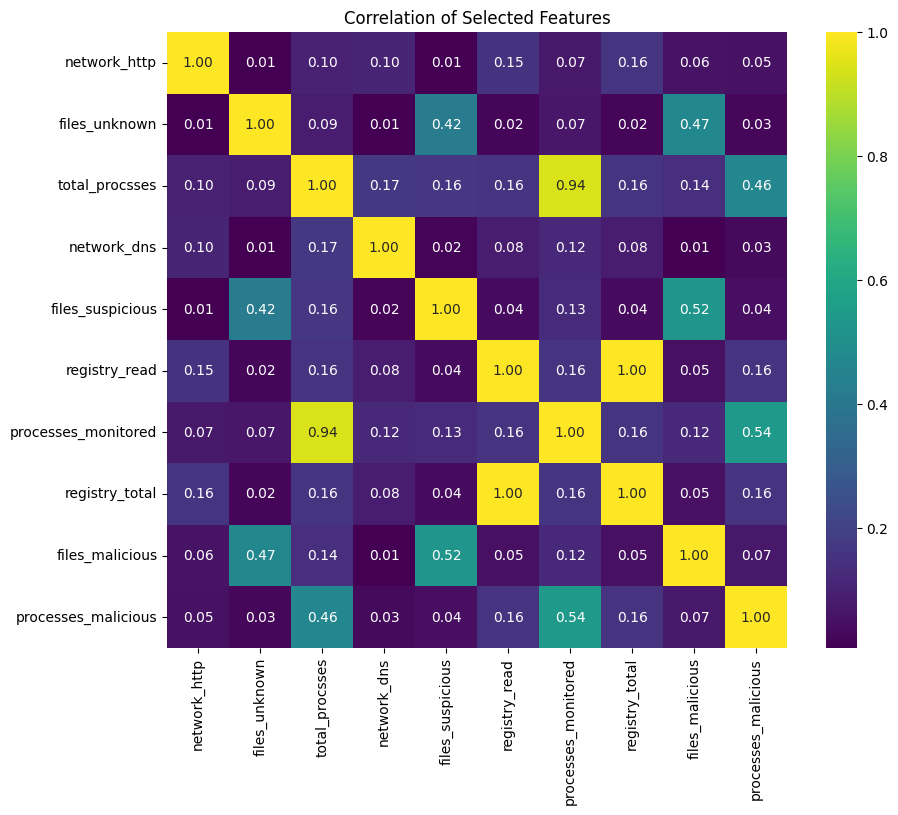

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

X_selected.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.suptitle("Distribution of Top Features", y=1.02)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(X_selected.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation of Selected Features")
plt.show()


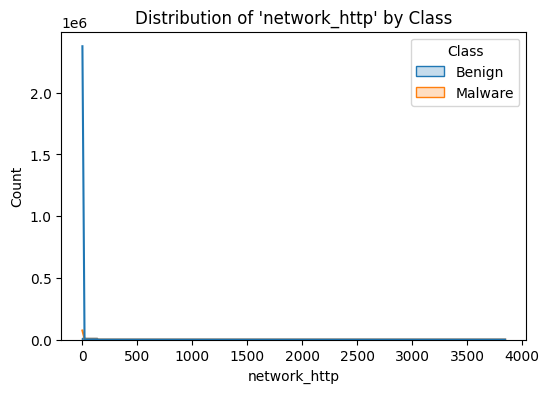

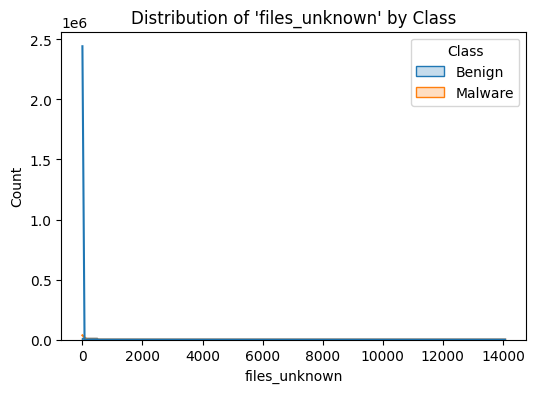

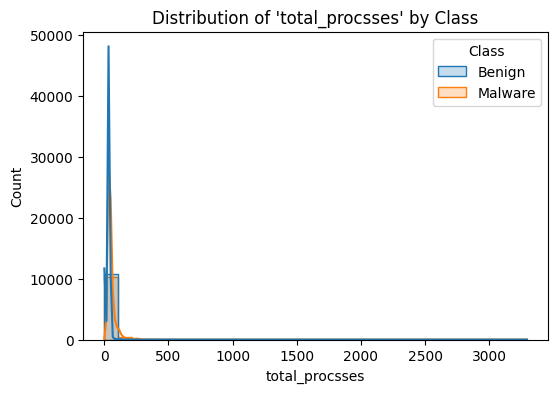

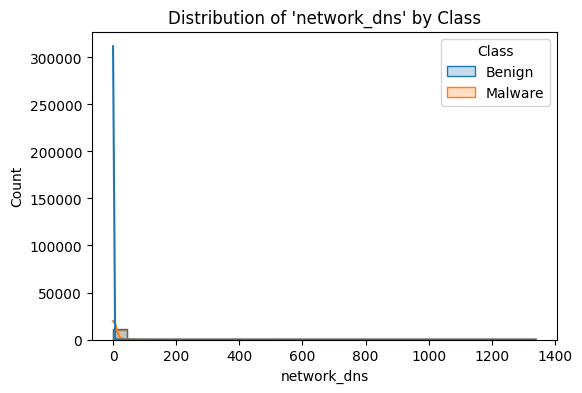

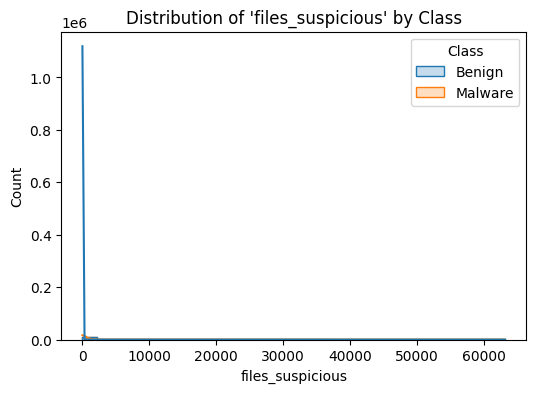

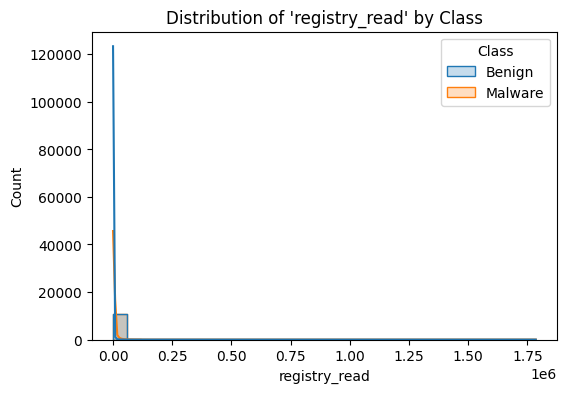

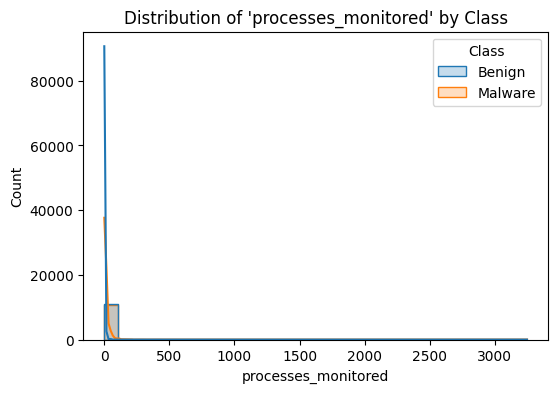

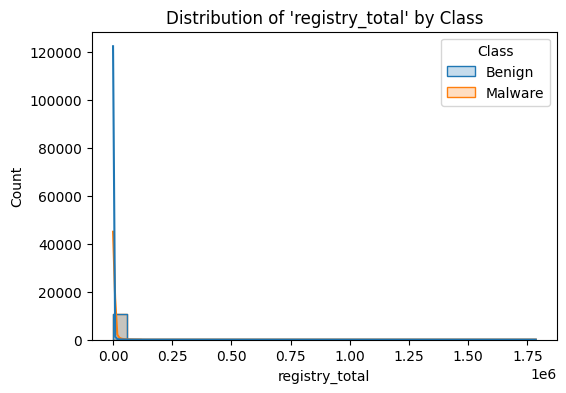

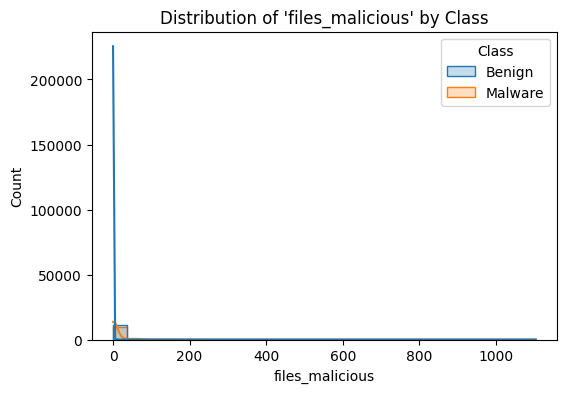

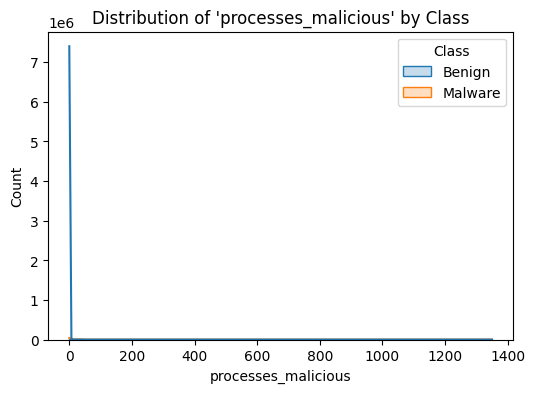

In [14]:
for feature in top_k_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, hue='Class', bins=30, kde=True, element='step', common_norm=False)
    plt.title(f"Distribution of '{feature}' by Class")
    plt.show()

In [15]:
import numpy as np
X_selected_log = X_selected.copy()
for col in X_selected.columns:
    X_selected_log[col] = np.log1p(X_selected_log[col])  
print(X_selected_log)

       network_http  files_unknown  total_procsses  network_dns  \
0          0.000000            0.0        0.000000     0.000000   
1          0.693147            0.0        4.543295     1.098612   
2          0.000000            0.0        3.583519     0.000000   
3          0.000000            0.0        0.000000     0.000000   
4          0.000000            0.0        3.610918     0.000000   
...             ...            ...             ...          ...   
21747      0.693147            0.0        3.401197     1.098612   
21748      0.693147            0.0        3.496508     1.098612   
21749      0.693147            0.0        3.583519     1.098612   
21750      0.693147            0.0        3.401197     1.098612   
21751      0.693147            0.0        3.526361     1.386294   

       files_suspicious  registry_read  processes_monitored  registry_total  \
0                   0.0       0.000000             0.000000        0.000000   
1                   0.0       1.79175

In [16]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number',
       'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header',
       'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value',
       'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number',
       'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion',
       'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem',
       'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit',
       'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags',
       'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData',
       'text_PointerToRawData', 'text_PointerToRelocations',
       'text_PointerToLineNumbers', 'text_Character

In [17]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 30:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 30:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [18]:
categorical_features,non_categorical_features,discrete_features,continuous_features = classify_features(df)
print("Categorical Features:",categorical_features)
print("Non-Categorical Features:",non_categorical_features)
print("Discrete Features:",discrete_features)
print("Continuous Features:",continuous_features)

Categorical Features: ['file_extension', 'PEType', 'MachineType', 'magic_number', 'Magic', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'Subsystem', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'rdata_PointerToRelocations', 'rdata_PointerToLineNumbers', 'Class', 'Category', 'Family']
Non-Categorical Features: ['EntryPoint', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRaw

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
model_bin = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_bin, y_pred_bin = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class.iloc[train_idx], y_class.iloc[test_idx]

    model_bin.fit(X_train, y_train)
    y_pred = model_bin.predict(X_test)

    y_true_bin.extend(y_test)
    y_pred_bin.extend(y_pred)

print("Classification Report of Decision Tree for Binary Classification:\n")
print(classification_report(y_true_bin, y_pred_bin))


Classification Report of Decision Tree for Binary Classification:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10876
           1       0.99      0.99      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_class, y_pred_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]  

    rf_class.fit(X_train, y_train)
    y_pred = rf_class.predict(X_test)

    y_true_class.extend(y_test)
    y_pred_class.extend(y_pred)

print("Classification Report of Random Forest for Binary Classification:\n")
print(classification_report(y_true_class, y_pred_class))


Classification Report of Random Forest for Binary Classification:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10876
           1       0.99      1.00      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_class = KNeighborsClassifier(n_neighbors=5)

y_true_knn_class, y_pred_knn_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]  

    knn_class.fit(X_train, y_train)
    y_pred = knn_class.predict(X_test)

    y_true_knn_class.extend(y_test)
    y_pred_knn_class.extend(y_pred)

print("KNN Classification Report for Binary Classification:\n")
print(classification_report(y_true_knn_class, y_pred_knn_class))


KNN Classification Report for Binary Classification:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     10876
           1       0.91      0.93      0.92     10876

    accuracy                           0.92     21752
   macro avg       0.92      0.92      0.92     21752
weighted avg       0.92      0.92      0.92     21752



In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_class = XGBClassifier(eval_metric='logloss', random_state=42)
y_true_xgb_class, y_pred_xgb_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]

    xgb_class.fit(X_train, y_train)
    y_pred = xgb_class.predict(X_test)

    y_true_xgb_class.extend(y_test)
    y_pred_xgb_class.extend(y_pred)

print("XGBoost Classification Report for Binary Classification:\n")
print(classification_report(y_true_xgb_class, y_pred_xgb_class))


XGBoost Classification Report for Binary Classification:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10876
           1       0.99      1.00      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



C:\Users\Gayathri\AppData\Local\Temp\ipykernel_19012\2423120207.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


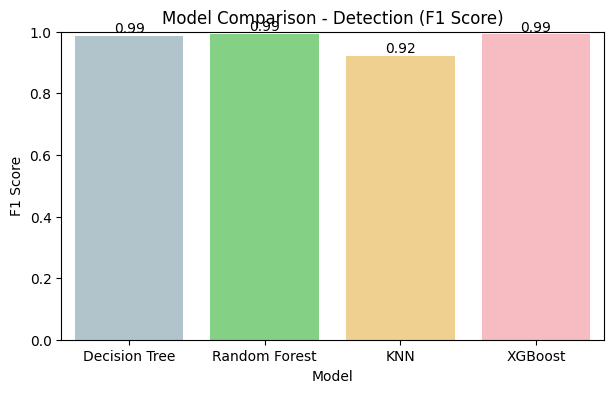


📊 Detection Model Performance Summary:
Decision Tree: 0.9873
Random Forest: 0.9929
KNN: 0.9216
XGBoost: 0.9927


In [24]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

models_det_results = {
    "Decision Tree": f1_score(y_true_bin, y_pred_bin),
    "Random Forest": f1_score(y_true_class, y_pred_class),
    "KNN": f1_score(y_true_knn_class, y_pred_knn_class),
    "XGBoost": f1_score(y_true_xgb_class, y_pred_xgb_class)
}

# Softer pastel colors
colors = ["#AEC6CF", "#77DD77", "#FFD580", "#FFB3BA"]

plt.figure(figsize=(7,4))
sns.barplot(
    x=list(models_det_results.keys()),
    y=list(models_det_results.values()),
    palette=colors
)

plt.title("Model Comparison - Detection (F1 Score)")
plt.ylabel("F1 Score")
plt.xlabel("Model")

# Show values on bars
for i, v in enumerate(models_det_results.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1)
plt.show()

print("\n📊 Detection Model Performance Summary:")
for model, score in models_det_results.items():
    print(f"{model}: {score:.4f}")

In [25]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model_family_dt = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_dt, y_pred_fam_dt = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    model_family_dt.fit(X_train, y_train)
    y_pred = model_family_dt.predict(X_test)

    y_true_fam_dt.extend(y_test)
    y_pred_fam_dt.extend(y_pred)

print("\n--- Family Classification Report (Decision Tree) ---")
print(classification_report(y_true_fam_dt, y_pred_fam_dt))



--- Family Classification Report (Decision Tree) ---
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       337
           1       0.99      0.99      0.99     10876
           2       0.81      0.84      0.82       332
           3       0.86      0.86      0.86       335
           4       0.84      0.86      0.85       505
           5       0.88      0.88      0.88       346
           6       0.85      0.85      0.85       473
           7       0.87      0.83      0.85       382
           8       0.69      0.69      0.69       454
           9       0.88      0.87      0.88       346
          10       0.82      0.84      0.83       444
          11       0.82      0.83      0.83       438
          12       0.88      0.88      0.88       290
          13       0.66      0.64      0.65       520
          14       0.92      0.90      0.91       550
          15       0.90      0.91      0.90       322
          16       0.84    

In [26]:

from sklearn.ensemble import RandomForestClassifier

rf_family = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_rf, y_pred_fam_rf = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    rf_family.fit(X_train, y_train)
    y_pred = rf_family.predict(X_test)

    y_true_fam_rf.extend(y_test)
    y_pred_fam_rf.extend(y_pred)

print("\n--- Family Classification Report (Random Forest) ---")
print(classification_report(y_true_fam_rf, y_pred_fam_rf))



--- Family Classification Report (Random Forest) ---
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       337
           1       0.99      0.99      0.99     10876
           2       0.86      0.89      0.87       332
           3       0.87      0.93      0.90       335
           4       0.91      0.92      0.92       505
           5       0.91      0.93      0.92       346
           6       0.91      0.93      0.92       473
           7       0.95      0.91      0.93       382
           8       0.76      0.73      0.75       454
           9       0.92      0.94      0.93       346
          10       0.91      0.86      0.88       444
          11       0.92      0.93      0.92       438
          12       0.94      0.95      0.95       290
          13       0.76      0.76      0.76       520
          14       0.96      0.94      0.95       550
          15       0.92      0.94      0.93       322
          16       0.90    

In [27]:

from sklearn.neighbors import KNeighborsClassifier

knn_family = KNeighborsClassifier(n_neighbors=3)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_knn, y_pred_fam_knn = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    knn_family.fit(X_train, y_train)
    y_pred = knn_family.predict(X_test)

    y_true_fam_knn.extend(y_test)
    y_pred_fam_knn.extend(y_pred)

print("\n--- Family Classification Report (KNN) ---")
print(classification_report(y_true_fam_knn, y_pred_fam_knn))



--- Family Classification Report (KNN) ---
              precision    recall  f1-score   support

           0       0.40      0.70      0.51       337
           1       0.87      0.94      0.90     10876
           2       0.45      0.58      0.51       332
           3       0.61      0.70      0.66       335
           4       0.63      0.70      0.66       505
           5       0.65      0.72      0.68       346
           6       0.79      0.71      0.75       473
           7       0.78      0.80      0.79       382
           8       0.59      0.49      0.54       454
           9       0.71      0.77      0.74       346
          10       0.65      0.59      0.61       444
          11       0.66      0.71      0.68       438
          12       0.74      0.76      0.75       290
          13       0.51      0.34      0.41       520
          14       0.85      0.77      0.80       550
          15       0.84      0.80      0.82       322
          16       0.68      0.65    

In [28]:

from xgboost import XGBClassifier

xgb_family = XGBClassifier(eval_metric='mlogloss', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_xgb, y_pred_fam_xgb = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    xgb_family.fit(X_train, y_train)
    y_pred = xgb_family.predict(X_test)

    y_true_fam_xgb.extend(y_test)
    y_pred_fam_xgb.extend(y_pred)

print("\n--- Family Classification Report (XGBoost) ---")
print(classification_report(y_true_fam_xgb, y_pred_fam_xgb))



--- Family Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       337
           1       0.99      0.99      0.99     10876
           2       0.88      0.88      0.88       332
           3       0.89      0.93      0.91       335
           4       0.92      0.91      0.91       505
           5       0.92      0.92      0.92       346
           6       0.93      0.94      0.93       473
           7       0.94      0.90      0.92       382
           8       0.74      0.73      0.74       454
           9       0.93      0.94      0.93       346
          10       0.92      0.85      0.88       444
          11       0.92      0.92      0.92       438
          12       0.93      0.93      0.93       290
          13       0.76      0.75      0.75       520
          14       0.96      0.95      0.96       550
          15       0.94      0.93      0.94       322
          16       0.92      0.91

C:\Users\Gayathri\AppData\Local\Temp\ipykernel_19012\594624277.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_fam_results.keys()), y=list(models_fam_results.values()), palette="coolwarm")


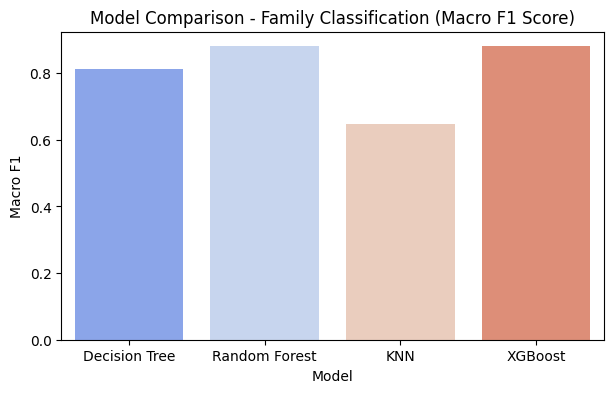


📊 Model Performance Summary:
Decision Tree: 0.8127
Random Forest: 0.8803
KNN: 0.6488
XGBoost: 0.8804


In [29]:

from sklearn.metrics import f1_score

models_fam_results = {
    "Decision Tree": f1_score(y_true_fam_dt, y_pred_fam_dt, average='macro'),
    "Random Forest": f1_score(y_true_fam_rf, y_pred_fam_rf, average='macro'),
    "KNN": f1_score(y_true_fam_knn, y_pred_fam_knn, average='macro'),
    "XGBoost": f1_score(y_true_fam_xgb, y_pred_fam_xgb, average='macro')
}

plt.figure(figsize=(7,4))
sns.barplot(x=list(models_fam_results.keys()), y=list(models_fam_results.values()), palette="coolwarm")
plt.title("Model Comparison - Family Classification (Macro F1 Score)")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.show()

print("\n📊 Model Performance Summary:")
for model, score in models_fam_results.items():
    print(f"{model}: {score:.4f}")


In [30]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import joblib

cols_to_drop = [col for col in ['Family', 'Class', 'md5', 'sha1'] if col in df.columns]

X_fam = df.drop(columns=cols_to_drop)
y_fam = df['Family']

encoders = {}

for col in X_fam.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_fam[col] = le.fit_transform(X_fam[col])
    encoders[col] = le

joblib.dump(encoders, "feature_encoders.pkl")

X_train_fam, X_test_fam, y_train_fam, y_test_fam = train_test_split(
    X_fam,
    y_fam,
    test_size=0.2,
    stratify=y_fam,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_fam, y_train_fam)

print("Before SMOTE:", y_train_fam.value_counts().head(5).to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().head(5).to_dict())

le_fam = LabelEncoder()

y_train_res_enc = le_fam.fit_transform(y_train_res)
y_test_fam_enc = le_fam.transform(y_test_fam)

Before SMOTE: {'Benign': 8700, 'Phobos': 440, 'Snake': 421, 'NanoCore': 416, 'Raccoon': 414}
After SMOTE: {'Benign': 8700, 'Shade': 8700, 'Phobos': 8700, 'Raccoon': 8700, 'Formbook': 8700}


In [31]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

selector_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_train_res, y_train_res_enc)

importances = selector_model.feature_importances_

feature_names = X_train_res.columns.tolist()

# ❌ Remove 'Category' feature if present
if 'Category' in feature_names:
    cat_index = feature_names.index('Category')
    importances = np.delete(importances, cat_index)
    feature_names.pop(cat_index)

# ✅ Change top_k to 15
top_k = 15

indices = np.argsort(importances)[::-1][:top_k]

selected_features = [feature_names[i] for i in indices]

print("Selected Features:")
for f in selected_features:
    print(f)

# Select columns using feature names (safe after removing Category)
X_train_sel = X_train_res[selected_features]
X_test_sel = X_test_fam[selected_features]

print(f"\nSelected top {top_k} important features for family classification.")

Selected Features:
DllCharacteristics
files_malicious
files_text
files_suspicious
SizeOfImage
processes_malicious
processes_monitored
apis
AddressOfEntryPoint
OperatingSystemVersion
address_of_ne_header
total_procsses
rdata_SizeOfRawData
rdata_VirtualSize
network_http

Selected top 15 important features for family classification.


In [32]:
# Get importances of selected features
selected_importances = importances[indices]

# Convert to percentage
total = selected_importances.sum()
contribution_percentages = (selected_importances / total) * 100

print("\nFeature Contribution Percentages (Family):")
for i, f in enumerate(selected_features):
    print(f"{f}: {contribution_percentages[i]:.2f}%")


Feature Contribution Percentages (Family):
DllCharacteristics: 8.80%
files_malicious: 8.65%
files_text: 8.34%
files_suspicious: 8.32%
SizeOfImage: 8.13%
processes_malicious: 7.49%
processes_monitored: 6.56%
apis: 6.34%
AddressOfEntryPoint: 6.16%
OperatingSystemVersion: 5.78%
address_of_ne_header: 5.32%
total_procsses: 5.13%
rdata_SizeOfRawData: 5.12%
rdata_VirtualSize: 5.08%
network_http: 4.78%


In [33]:
from sklearn.preprocessing import StandardScaler

scaler_fam_sel = StandardScaler()

X_train_sel = scaler_fam_sel.fit_transform(X_train_sel)
X_test_sel = scaler_fam_sel.transform(X_test_sel)

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score

dt_family = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

dt_family.fit(X_train_sel, y_train_res_enc)

y_pred_dt = dt_family.predict(X_test_sel)

print("\nDecision Tree (Family Classification)")

print(classification_report(y_test_fam_enc, y_pred_dt))

macro_f1 = f1_score(y_test_fam_enc, y_pred_dt, average='macro')

print("Macro F1:", macro_f1)


Decision Tree (Family Classification)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      0.98      0.99      2176
           2       0.93      0.85      0.89        66
           3       0.90      0.93      0.91        67
           4       0.95      0.96      0.96       101
           5       0.92      0.83      0.87        69
           6       0.90      0.95      0.92        95
           7       0.93      0.92      0.93        76
           8       0.75      0.84      0.79        91
           9       0.93      0.90      0.91        69
          10       0.87      0.93      0.90        89
          11       0.93      0.90      0.91        88
          12       0.95      0.97      0.96        58
          13       0.70      0.77      0.73       104
          14       0.92      0.98      0.95       110
          15       0.96      0.86      0.91        64
          16       0.86      0.93      0.9

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

rf_family = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_family.fit(X_train_sel, y_train_res_enc)

y_pred_rf = rf_family.predict(X_test_sel)

y_pred_rf_labels = le_fam.inverse_transform(y_pred_rf)
y_test_labels = le_fam.inverse_transform(y_test_fam_enc)

print("\n Random Forest (Family Classification) ")

print(classification_report(y_test_labels, y_pred_rf_labels))

macro_f1 = f1_score(y_test_fam_enc, y_pred_rf, average='macro')

print("Macro F1:", macro_f1)


 Random Forest (Family Classification) 
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      0.98      0.99      2176
      Cerber       1.00      0.92      0.96        66
    DarkSide       1.00      0.99      0.99        67
      Dharma       1.00      0.99      1.00       101
      Emotet       0.95      0.91      0.93        69
    Formbook       0.98      0.97      0.97        95
    Gandcrab       0.96      1.00      0.98        76
       Gh0st       0.91      0.91      0.91        91
    Glupteba       1.00      0.97      0.99        69
    Guloader       0.94      0.99      0.96        89
     LockBit       0.96      0.99      0.97        88
        Maze       0.95      1.00      0.97        58
    NanoCore       0.82      0.89      0.85       104
      Phobos       0.96      0.98      0.97       110
        Qbot       0.94      0.94      0.94        64
       REvil       0.99      0.96      0

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

knn_family = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)
knn_family.fit(X_train_sel, y_train_res_enc)

y_pred_knn = knn_family.predict(X_test_sel)

y_pred_knn_labels = le_fam.inverse_transform(y_pred_knn)
y_test_labels = le_fam.inverse_transform(y_test_fam_enc)

print("\n KNN (Family Classification) ")

print(classification_report(y_test_labels, y_pred_knn_labels))

print("Macro F1:", f1_score(y_test_fam_enc, y_pred_knn, average='macro'))


 KNN (Family Classification) 
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       0.98      0.76      0.85      2176
      Cerber       0.87      0.89      0.88        66
    DarkSide       0.84      0.93      0.88        67
      Dharma       0.90      0.93      0.92       101
      Emotet       0.47      0.70      0.56        69
    Formbook       0.86      0.94      0.90        95
    Gandcrab       0.83      0.89      0.86        76
       Gh0st       0.48      0.82      0.60        91
    Glupteba       0.84      0.90      0.87        69
    Guloader       0.77      0.92      0.84        89
     LockBit       0.93      0.90      0.91        88
        Maze       0.89      0.97      0.93        58
    NanoCore       0.43      0.75      0.55       104
      Phobos       0.96      0.98      0.97       110
        Qbot       0.61      0.80      0.69        64
       REvil       0.74      0.91      0.82       

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

xgb_family = XGBClassifier(
    eval_metric='mlogloss',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_family.fit(X_train_sel, y_train_res_enc)

y_pred_xgb = xgb_family.predict(X_test_sel)

y_pred_xgb_labels = le_fam.inverse_transform(y_pred_xgb)
y_test_labels = le_fam.inverse_transform(y_test_fam_enc)

print("\n XGBoost (Family Classification) ")

print(classification_report(y_test_labels, y_pred_xgb_labels))

print("Macro F1:", f1_score(y_test_fam_enc, y_pred_xgb, average='macro'))


 XGBoost (Family Classification) 
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      0.99      0.99      2176
      Cerber       0.98      0.91      0.94        66
    DarkSide       0.99      0.99      0.99        67
      Dharma       0.99      0.98      0.99       101
      Emotet       0.96      0.93      0.94        69
    Formbook       0.96      0.98      0.97        95
    Gandcrab       0.96      0.99      0.97        76
       Gh0st       0.93      0.92      0.93        91
    Glupteba       0.94      0.99      0.96        69
    Guloader       0.98      1.00      0.99        89
     LockBit       0.96      1.00      0.98        88
        Maze       0.97      0.98      0.97        58
    NanoCore       0.85      0.89      0.87       104
      Phobos       0.99      0.98      0.99       110
        Qbot       0.98      0.94      0.96        64
       REvil       0.99      0.96      0.97   

C:\Users\Gayathri\AppData\Local\Temp\ipykernel_19012\3031642205.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


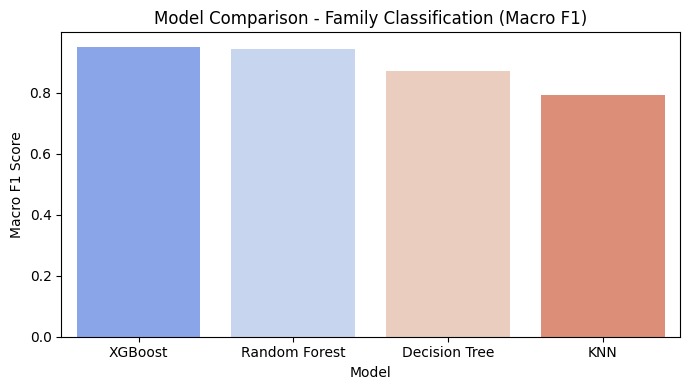


Model Performance Summary:
Decision Tree: 0.8723
Random Forest: 0.9427
KNN: 0.7931
XGBoost: 0.9500


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test_fam_enc, y_pred_dt, average='macro')
rf_f1 = f1_score(y_test_fam_enc, y_pred_rf, average='macro')
knn_f1 = f1_score(y_test_fam_enc, y_pred_knn, average='macro')
xgb_f1 = f1_score(y_test_fam_enc, y_pred_xgb, average='macro')

models_fam = {
    "Decision Tree": dt_f1,
    "Random Forest": rf_f1,
    "KNN": knn_f1,
    "XGBoost": xgb_f1
}

results_df = pd.DataFrame(
    list(models_fam.items()),
    columns=["Model", "Macro F1"]
)

results_df = results_df.sort_values(by="Macro F1", ascending=False)

plt.figure(figsize=(7,4))

sns.barplot(
    data=results_df,
    x="Model",
    y="Macro F1",
    palette="coolwarm"
)

plt.title("Model Comparison - Family Classification (Macro F1)")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")

plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")
for model, score in models_fam.items():
    print(f"{model}: {score:.4f}")

In [39]:
import numpy as np

label_map = {0: "Benign", 1: "Ransomware"}

sample_index = np.random.randint(0, len(X_selected))
sample_det = X_selected.iloc[[sample_index]]   

pred_det = xgb_class.predict(sample_det.values)[0]

pred_det_label = label_map.get(int(pred_det), "Unknown")

print("\n Detection Stage ")
print(f"Sample Index: {sample_index}")
print(f"Predicted Detection Label: {pred_det_label}")


 Detection Stage 
Sample Index: 20089
Predicted Detection Label: Ransomware


In [40]:
import numpy as np

sample_index_fam = np.random.randint(0, len(X_test_fam))

sample_fam = X_test_fam.iloc[[sample_index_fam]]

sample_fam_selected = sample_fam.values[:, indices]

sample_fam_scaled = scaler_fam_sel.transform(sample_fam_selected)

pred_fam_enc = xgb_family.predict(sample_fam_scaled)[0]

pred_fam_label = le_fam.inverse_transform([pred_fam_enc])[0]

print("\n--- Family Classification Stage ---")
print(f"Sample Index: {sample_index_fam}")
print(f"Predicted Family: {pred_fam_label}")


--- Family Classification Stage ---
Sample Index: 2471
Predicted Family: Guloader


c:\Users\Gayathri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
import joblib

# Load required objects
joblib.dump(scaler_fam_sel, "scaler_fam.pkl") 
scaler_fam = joblib.load("scaler_fam.pkl")

def predict_pipeline_final():

    label_map = {0: "Benign", 1: "Ransomware"}

    det_index = np.random.randint(0, len(X_selected))
    sample_det = X_selected.iloc[[det_index]]

    pred_det = xgb_class.predict(sample_det.values)[0]
    pred_det_label = label_map.get(int(pred_det), "Unknown")

    print("\nDetection Stage")
    print(f"Detection Sample Index : {det_index}")
    print(f"Predicted Detection    : {pred_det_label}")

    actual_det = y_class.iloc[det_index]
    print(f"Actual Detection       : {label_map.get(int(actual_det))}")

    if pred_det_label == "Benign":
        print("\nResult: Benign file. No ransomware family classification required.")
        return

    fam_index = np.random.randint(0, len(X_test_fam))
    sample_fam = X_test_fam.iloc[[fam_index]]

    # 🔥 IMPORTANT FIX (based on your pipeline)
    sample_fam_selected = sample_fam.values[:, indices]

    sample_fam_scaled = scaler_fam.transform(sample_fam_selected)

    pred_fam_enc = xgb_family.predict(sample_fam_scaled)[0]
    pred_fam_label = le_fam.inverse_transform([pred_fam_enc])[0]

    print("\nFamily Classification Stage")
    print(f"Family Sample Index : {fam_index}")
    print(f"Predicted Family    : {pred_fam_label}")

    actual_family = y_test_fam.iloc[fam_index]
    print(f"Actual Family       : {actual_family}")

    print("\nFinal Result: Ransomware detected and classified successfully.")

In [42]:
predict_pipeline_final()


Detection Stage
Detection Sample Index : 5755
Predicted Detection    : Benign
Actual Detection       : Benign

Result: Benign file. No ransomware family classification required.


In [43]:
import joblib

joblib.dump(xgb_class, "xgb_class.pkl")
joblib.dump(xgb_family, "xgb_family.pkl")

joblib.dump(scaler_fam_sel, "scaler_fam.pkl") 
joblib.dump(le_fam, "le_fam.pkl")
joblib.dump(indices, "feature_indices.pkl")
joblib.dump(encoders, "feature_encoders.pkl")

print("Models and preprocessors saved successfully.")

Models and preprocessors saved successfully.
